### 1. Import necessary libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### 2. Generate a synthetic dataset

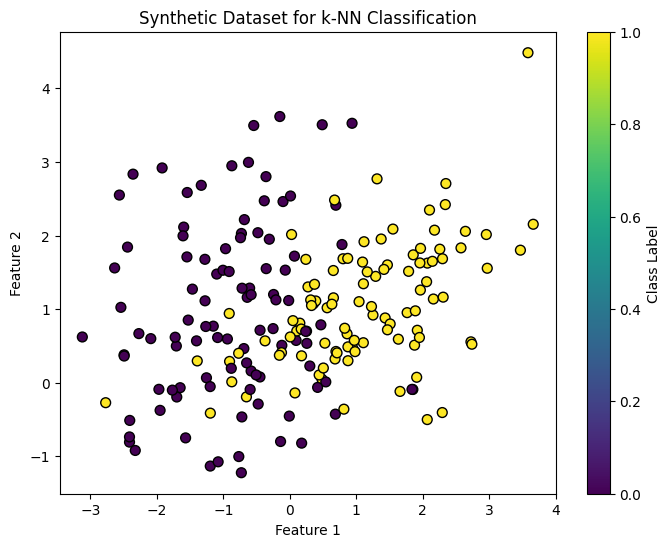

In [ ]:
# Generate a synthetic dataset for binary classification
X, y = make_classification(
    n_samples=200,      # Number of samples
    n_features=2,       # Number of features
    n_informative=2,    # Number of informative features
    n_redundant=0,      # Number of redundant features
    n_clusters_per_class=1, # Number of clusters per class
    random_state=42     # For reproducibility
)

# Visualize the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, edgecolors='k')
plt.title('Synthetic Dataset for k-NN Classification')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class Label')
plt.show()

### 3. Split the data into training and testing sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 140 samples
Testing set size: 60 samples


### 4. Initialize and train the k-NN classifier

In [ ]:
# Choose a value for k (number of neighbors)
k = 5
knn_classifier = KNeighborsClassifier(n_neighbors=k)

# Train the model
knn_classifier.fit(X_train, y_train)

print(f"k-NN classifier initialized with k={k} and trained.")

k-NN classifier initialized with k=5 and trained.


### 5. Make predictions on the test set

In [ ]:
y_pred = knn_classifier.predict(X_test)

print("Predictions made on the test set.")
# print(f"Sample predictions: {y_pred[:10]}")

Predictions made on the test set.


### 6. Evaluate the model

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8000

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.76      0.81        34
           1       0.73      0.85      0.79        26

    accuracy                           0.80        60
   macro avg       0.80      0.81      0.80        60
weighted avg       0.81      0.80      0.80        60


Confusion Matrix:
[[26  8]
 [ 4 22]]


### 7. Visualize the decision boundary (Optional)

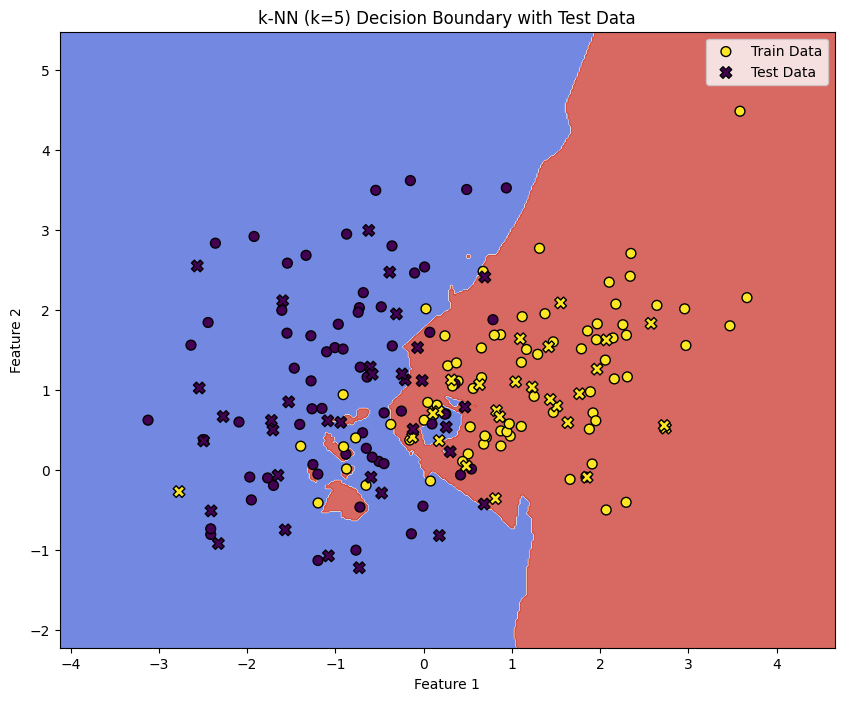

In [ ]:
# Create a meshgrid to plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict class for each point in the meshgrid
Z = knn_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the data points
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', s=50, edgecolors='k', label='Train Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', s=70, marker='X', edgecolors='k', label='Test Data')
plt.title(f'k-NN (k={k}) Decision Boundary with Test Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()